In [ ]:
from huggingface_hub import notebook_login
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 5.21 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 159.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 163.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existin

In [ ]:
!pip install harmonypy scib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 18.5 MB/s eta 0:00:00


### Load merged data and split into human and monkey

In [ ]:
colon_path = "/content/drive/MyDrive/GP_datasets/Colon/colon_merged.h5ad"

In [ ]:
import scanpy as sc
adata_colon = sc.read_h5ad(colon_path)
print(adata_colon)

AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'


In [ ]:
# split into human and monkey
adata_monkey_un = adata_colon[adata_colon.obs["species"] == "monkey"]
adata_human_un = adata_colon[adata_colon.obs["species"] == "human"]
# save to drive
adata_monkey_un.write("/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_monkey.h5ad")
adata_human_un.write("/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human.h5ad")

In [ ]:
import scanpy as sc

human_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human.h5ad"

monkey_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_monkey.h5ad"

In [ ]:
adata_monkey = sc.read_h5ad(monkey_path)
print(adata_monkey)

AnnData object with n_obs × n_vars = 6567 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'


In [ ]:
adata_human = sc.read_h5ad(human_path)
print(adata_human)

AnnData object with n_obs × n_vars = 26069 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'


### Check data and remove any problematic cells

In [ ]:
import numpy as np
import scipy.sparse as sp

# ---------- clean copy ----------
adata_clean = adata_human.copy()

# 1) make gene names unique
adata_clean.var_names_make_unique()

# 2) clean X
X = adata_clean.X.copy()

if sp.issparse(X):
    X = X.tocsr()
    X.data = np.nan_to_num(X.data, nan=0.0, posinf=0.0, neginf=0.0)

    # clip tiny values
    X.data[X.data < 1e-12] = 0

    # remove zero entries explicitly
    X.eliminate_zeros()

    # row std
    row_mean = np.array(X.mean(axis=1)).flatten()
    row_sq_mean = np.array(X.power(2).mean(axis=1)).flatten()
    row_std = np.sqrt(np.maximum(row_sq_mean - row_mean**2, 0))

else:
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X[X < 1e-12] = 0
    row_std = X.std(axis=1)

adata_clean.X = X

# 3) remove flat/problematic cells
keep = row_std > 1e-8
print("Removed cells:", (~keep).sum())

adata_clean = adata_clean[keep].copy()

# 4) add counts layer for UCE
adata_clean.layers["counts"] = adata_clean.X.copy()

# 5) save new file
new_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_clean_for_UCE.h5ad"
adata_clean.write_h5ad(new_path)

print("Saved:", new_path)
print("Final shape:", adata_clean.shape)

Removed cells: 0
Saved: /content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_clean_for_UCE.h5ad
Final shape: (26069, 12502)


In [ ]:
print(adata_human.var_names[:20].tolist())
print(adata_monkey.var_names[:20].tolist())

['TSPAN6', 'DPM1', 'SCYL3', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1', 'NIPAL3', 'LAS1L', 'ENPP4', 'SEMA3F', 'CFTR', 'ANKIB1', 'CYP51A1', 'KRIT1', 'RAD52', 'BAD', 'LAP3']
['TSPAN6', 'DPM1', 'SCYL3', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1', 'NIPAL3', 'LAS1L', 'ENPP4', 'SEMA3F', 'CFTR', 'ANKIB1', 'CYP51A1', 'KRIT1', 'RAD52', 'BAD', 'LAP3']


In [ ]:
import numpy as np
import scipy.sparse as sp

adata_fix = adata_human.copy()

X = adata_fix.X.copy()

# handle sparse correctly
if sp.issparse(X):
    X = X.tocsr()

    # zero out tiny values safely
    X.data[X.data < 0.01] = 0

    # remove explicit zeros
    X.eliminate_zeros()

else:
    X[X < 0.01] = 0
    X = sp.csr_matrix(X)

adata_fix.X = X

# add counts layer
adata_fix.layers["counts"] = adata_fix.X.copy()

# save
new_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_sparse_for_UCE.h5ad"
adata_fix.write_h5ad(new_path)

print("Saved:", new_path)
print("Shape:", adata_fix.shape)
print("Nonzeros:", adata_fix.X.nnz)
print("Sparsity:", 100*(1 - adata_fix.X.nnz/(adata_fix.n_obs*adata_fix.n_vars)), "%")
print("saved:", new_path)

Saved: /content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_sparse_for_UCE.h5ad
Shape: (26069, 12502)
Nonzeros: 48170926
Sparsity: 85.21977217850521 %
saved: /content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_sparse_for_UCE.h5ad


In [ ]:
print(adata_human.obs_names[:40].tolist())
print(adata_human.obs_names[700:740].tolist())

['TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_B20', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_L10', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_G16', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_P21', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_B18', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_G21', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_J1', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_I16', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_M19', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_K14', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_K2', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_G14', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_I5', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_E17', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_N3', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_F3', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_O11', 'TSP14_LI_proximal_SS2_B134547_D101532_Epithelial_G2

In [ ]:
print(adata_human.obs.head())
print(adata_human.obs.iloc[700:710])

                                                     cell_type species  \
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Enterocyte   human   
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Enterocyte   human   
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Enterocyte   human   
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Enterocyte   human   
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Enterocyte   human   

                                                         assay  
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Smart-seq2  
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Smart-seq2  
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Smart-seq2  
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Smart-seq2  
TSP14_LI_proximal_SS2_B134547_D101532_Epithelia...  Smart-seq2  
                                                     cell_type species  \
TSP14_LI_distal_SS2_B134545_B002622_Epithelial_I16  Enterocyte   human   
TSP14_LI_distal_S

In [ ]:
print(adata_human.obs["assay"].value_counts())
print()
print(adata_monkey.obs["assay"].value_counts())

assay
10x 3' v3     24599
Smart-seq2     1470
Name: count, dtype: int64

assay
10x Chromium    6567
Name: count, dtype: int64


### Save clean version

In [ ]:
adata_human_uce = adata_human[adata_human.obs["assay"] != "Smart-seq2"].copy()
adata_human_uce.layers["counts"] = adata_human_uce.X.copy()

save_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_10x_only.h5ad"
adata_human_uce.write_h5ad(save_path)

print(adata_human_uce.shape)

(24599, 12502)


## Run UCE model on fixed data

In [ ]:
! python eval_single_anndata.py --adata_path "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_human_10x_only.h5ad" --dir "./"  --model_loc "minwoosun/uce-100m"


Download Complete!
Proccessing Colon_human_10x_only
8.878773
Colon_human_10x_only (24599, 12292)
Wrote Shapes Dict
12292
Max Code: 612
Loaded model:
minwoosun/uce-100m
100% 984/984 [02:56<00:00,  5.57it/s]
*****Wrote Anndata to:*****
./Colon_human_10x_only_uce_adata.h5ad


In [ ]:
! python eval_single_anndata.py --adata_path "/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Colon_monkey.h5ad" --dir "./"  --species "macaca_fascicularis" --model_loc "minwoosun/uce-100m"


species_chrom.csv: 4.10MB [00:00, 15.2MB/s]
all_tokens.torch: 100% 2.98G/2.98G [00:58<00:00, 50.6MB/s]
species_offsets.pkl: 100% 139/139 [00:01<00:00, 109B/s]
protein_embeddings/Danio_rerio.GRCz11.ge(…): 100% 537M/537M [00:23<00:00, 23.1MB/s]
protein_embeddings/Homo_sapiens.GRCh38.g(…): 100% 411M/411M [00:03<00:00, 108MB/s]
protein_embeddings/Macaca_fascicularis.M(…): 100% 315M/315M [00:24<00:00, 12.7MB/s]
protein_embeddings/Macaca_mulatta.Mmul_1(…): 100% 348M/348M [00:13<00:00, 25.6MB/s]
protein_embeddings/Microcebus_murinus.Mm(…): 100% 302M/302M [00:16<00:00, 18.0MB/s]
protein_embeddings/Mus_musculus.GRCm39.g(…): 100% 464M/464M [01:03<00:00, 7.33MB/s]
protein_embeddings/Sus_scrofa.Sscrofa11.(…): 100% 327M/327M [00:14<00:00, 23.0MB/s]
protein_embeddings/Xenopus_tropicalis.Xe(…): 100% 281M/281M [00:13<00:00, 20.6MB/s]
Download Complete!
Proccessing Colon_monkey
9.097999
Colon_monkey (6567, 10047)
Wrote Shapes Dict
10047
Max Code: 653
config.json: 100% 115/115 [00:00<00:00, 393kB/s]
pyt

In [ ]:
# write embeddings to drive
import scanpy as sc
adata_monkey = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/Colon_monkey_embeddings_uce.h5ad")
print(adata_monkey)


AnnData object with n_obs × n_vars = 6567 × 10047
    obs: 'cell_type', 'species', 'assay', 'n_genes'
    var: 'n_cells'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_uce', 'X_umap'
    obsp: 'connectivities', 'distances'


In [ ]:
import scanpy as sc

# Read the .h5ad file
adata_human = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/Colon_human_embeddings_uce.h5ad")
print(adata_human)

AnnData object with n_obs × n_vars = 24599 × 12292
    obs: 'cell_type', 'species', 'assay', 'n_genes'
    var: 'n_cells'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_uce', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [ ]:
import anndata as ad

adata = ad.concat(
    [adata_monkey, adata_human],
    axis=0,
    join="inner",
    merge="same",
    label="species",
    keys=["monkey", "human"],
    index_unique="-",
)



In [ ]:
print(adata_human.obsm["X_uce"].shape)

(24599, 1280)


In [ ]:
print(adata_monkey.obsm["X_uce"].shape)

(6567, 1280)


In [ ]:
print(adata.obsm["X_uce"].shape)

(31166, 1280)


In [ ]:
print(f"Combined shape: {adata.shape}")
adata.obs[["cell_type", "species"]].value_counts()

Combined shape: (31166, 9984)


cell_type               species
T cell                  human      9785
Enterocyte              human      4759
Plasma cell             monkey     3698
                        human      3198
Stromal cell            human      2527
B cell                  human      2063
Enteric glial cell      human       804
T cell                  monkey      740
Monocyte                human       725
Stromal cell            monkey      407
Enterocyte              monkey      405
Mast cell               human       392
Monocyte                monkey      334
B cell                  monkey      326
Endothelial cell        monkey      275
                        human       256
Myeloid dendritic cell  monkey      137
Smooth muscle cell      monkey      126
Enteric glial cell      monkey       70
Smooth muscle cell      human        51
Mast cell               monkey       49
Myeloid dendritic cell  human        39
Name: count, dtype: int64

In [ ]:
adata.obs["cell_type"].value_counts()

,count
cell_type,
T cell,10525
Plasma cell,6896
Enterocyte,5164
Stromal cell,2934
B cell,2389
Monocyte,1059
Enteric glial cell,874
Endothelial cell,531
Mast cell,441


In [ ]:
adata_human.obs['cell_type'].value_counts()

,count
cell_type,
T cell,9785
Enterocyte,4759
Plasma cell,3198
Stromal cell,2527
B cell,2063
Enteric glial cell,804
Monocyte,725
Mast cell,392
Endothelial cell,256


In [ ]:
adata_monkey.obs['cell_type'].value_counts()

,count
cell_type,
Plasma cell,3698
T cell,740
Stromal cell,407
Enterocyte,405
Monocyte,334
B cell,326
Endothelial cell,275
Myeloid dendritic cell,137
Smooth muscle cell,126


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values

        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [ ]:
label_keys = ["cell_type","species"]
# Compute scores
scores = compute_silhouette_and_lisi_avg(adata, label_keys, embed_key="X_uce", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
adata

AnnData object with n_obs × n_vars = 31166 × 9984
    obs: 'cell_type', 'species', 'assay', 'n_genes'
    obsm: 'X_pca', 'X_uce', 'X_umap'

# Human --> Monkey

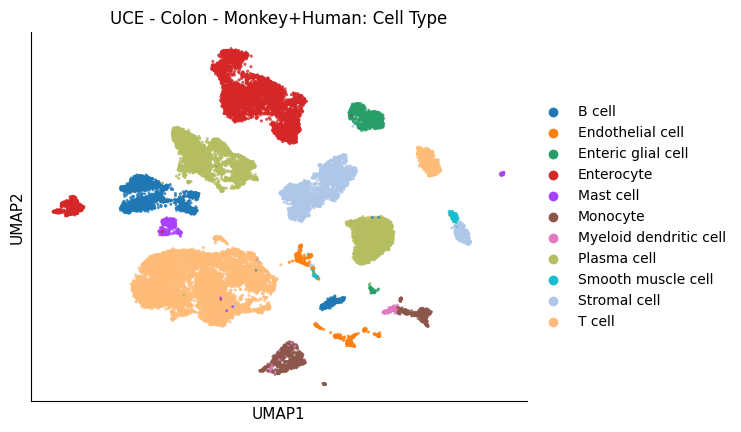

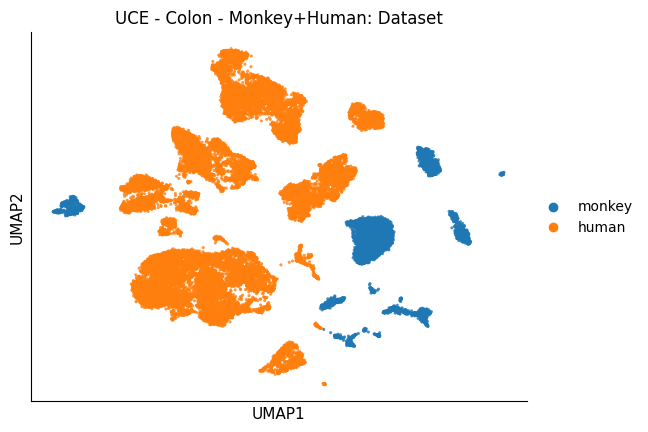

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
Accuracy: 0.9594944419065022
                        precision    recall  f1-score   support

                B cell       0.98      0.97      0.98       326
      Endothelial cell       0.99      0.86      0.92       275
    Enteric glial cell       0.96      0.99      0.97        70
            Enterocyte       0.99      1.00      0.99       405
             Mast cell       1.00      1.00      1.00        49
              Monocyte       0.89      0.92      0.90       334
Myeloid dendritic cell       0.80      0.69      0.74       137
           Plasma cell       1.00      1.00      1.00      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.75      1.00      0.86       407
                T cell       0.99      0.99      0.99       740

              accuracy                           0.96      6567
             macro avg       0.85      0.86      0.85      6567
          weighted avg       0.95      0.96  

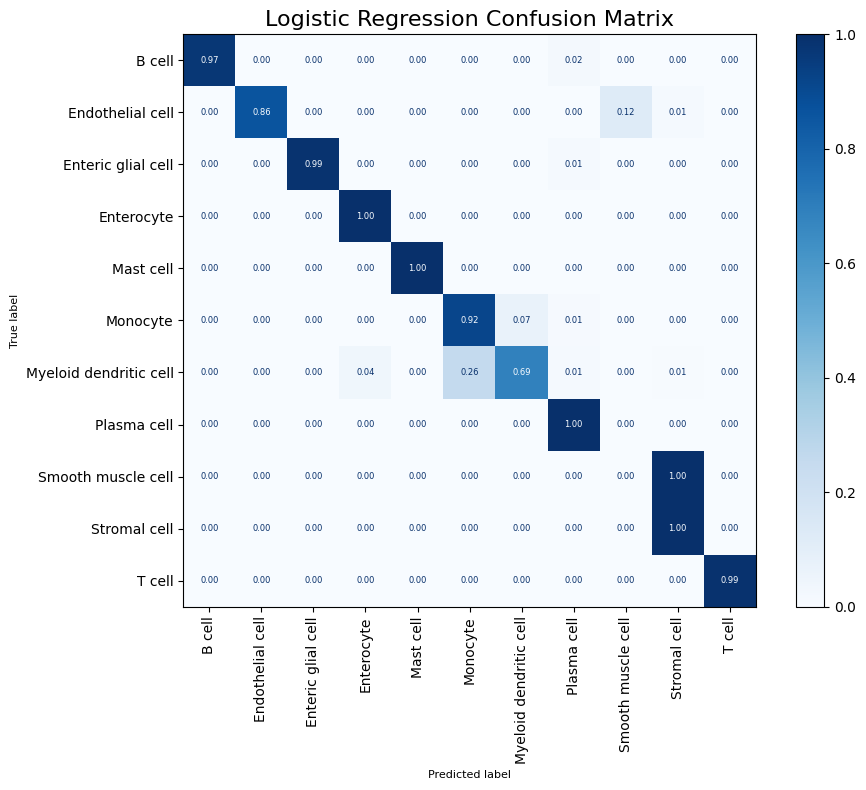


=== k-NN ===
Accuracy: 0.9404598751332419
                        precision    recall  f1-score   support

                B cell       0.98      0.97      0.97       326
      Endothelial cell       0.98      0.81      0.89       275
    Enteric glial cell       0.95      0.99      0.97        70
            Enterocyte       1.00      1.00      1.00       405
             Mast cell       0.94      1.00      0.97        49
              Monocyte       0.69      0.84      0.76       334
Myeloid dendritic cell       0.23      0.10      0.14       137
           Plasma cell       1.00      1.00      1.00      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.75      1.00      0.86       407
                T cell       0.99      0.99      0.99       740

              accuracy                           0.94      6567
             macro avg       0.77      0.79      0.78      6567
          weighted avg       0.93      0.94      0.93      

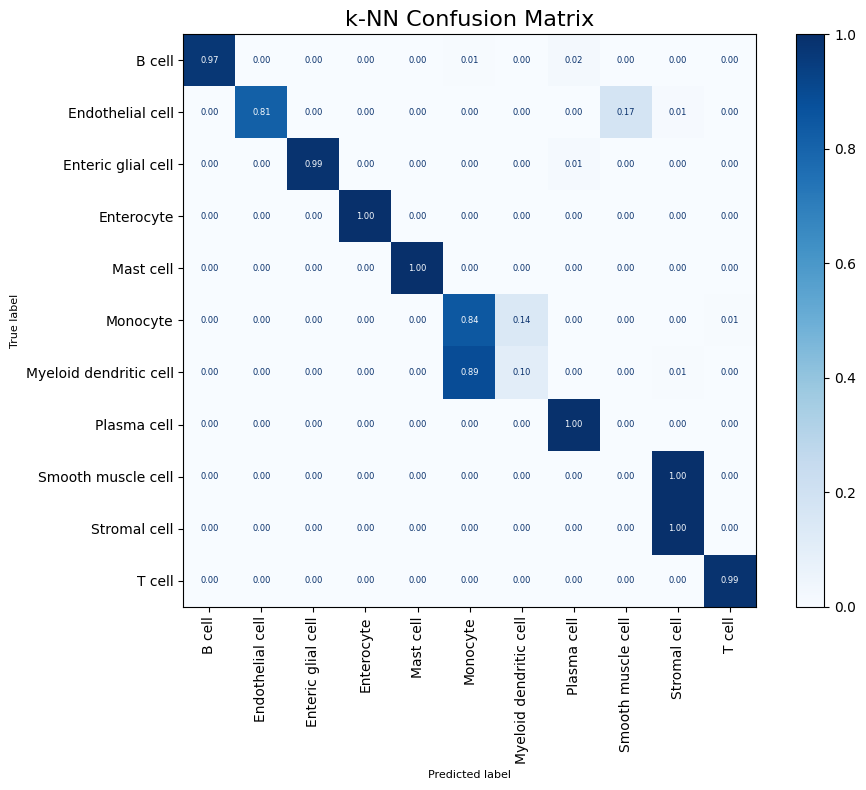

/tmp/ipykernel_822/1134646885.py:133: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


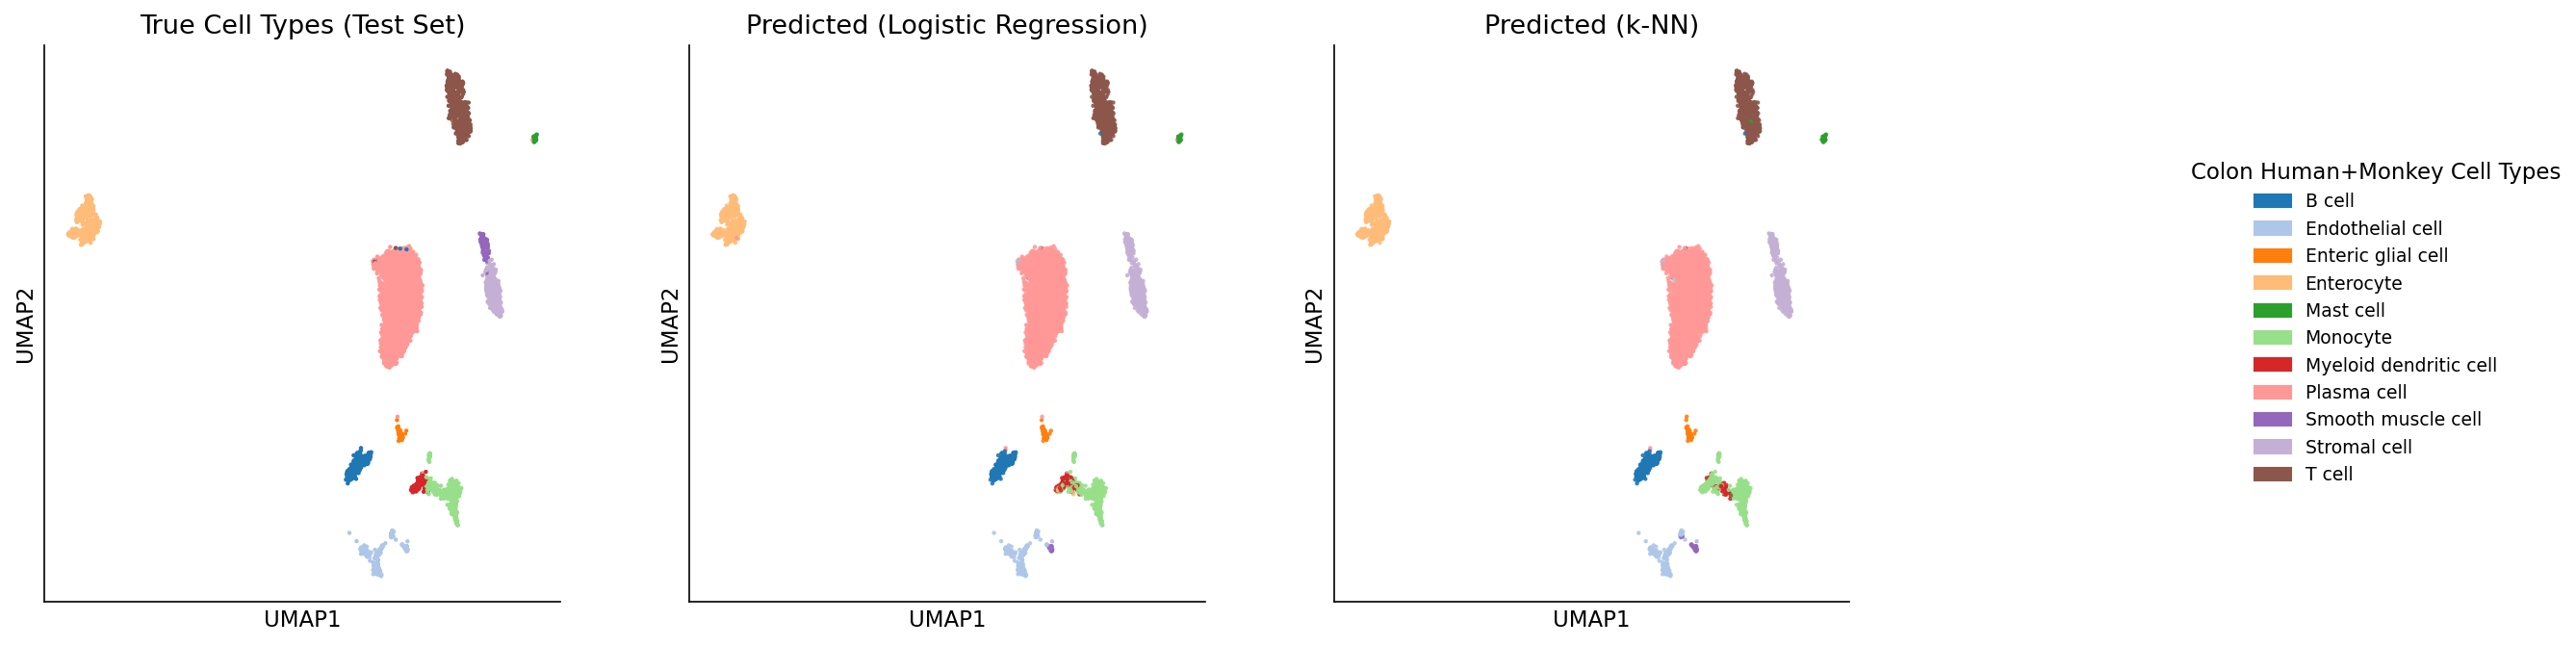

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
## Visualization

sc.pp.neighbors(adata, use_rep="X_uce")
sc.tl.umap(adata)

ax = sc.pl.umap(
    adata,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="UCE - Colon - Monkey+Human: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='species',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="UCE - Colon - Monkey+Human: Dataset"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata[adata.obs["species"] != "monkey"]
test_data  = adata[adata.obs["species"] == "monkey"]

X_train = train_data.obsm["X_uce"]
X_test  = test_data.obsm["X_uce"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Colon Human+Monkey Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

# Monkey --> Human

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
Accuracy: 0.94934753445262
                        precision    recall  f1-score   support

                B cell       0.99      1.00      0.99      2063
      Endothelial cell       0.77      0.99      0.87       256
    Enteric glial cell       0.99      1.00      0.99       804
            Enterocyte       1.00      1.00      1.00      4759
             Mast cell       1.00      0.92      0.96       392
              Monocyte       0.94      0.98      0.96       725
Myeloid dendritic cell       0.25      0.03      0.05        39
           Plasma cell       1.00      1.00      1.00      3198
    Smooth muscle cell       0.00      0.00      0.00        51
          Stromal cell       1.00      0.57      0.73      2527
                T cell       0.99      1.00      1.00      9785

              accuracy                           0.95     24599
             macro avg       0.81      0.77      0.78     24599
          weighted avg       0.99      0.95    

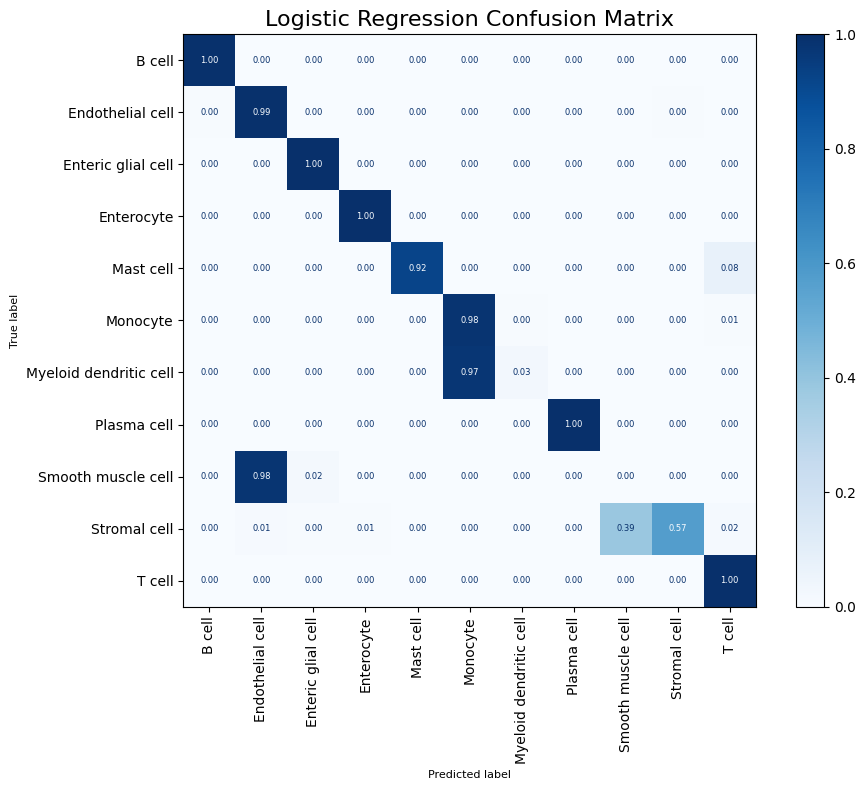


=== k-NN ===
Accuracy: 0.9550794747753973
                        precision    recall  f1-score   support

                B cell       0.99      1.00      0.99      2063
      Endothelial cell       0.80      0.99      0.88       256
    Enteric glial cell       0.98      1.00      0.99       804
            Enterocyte       1.00      1.00      1.00      4759
             Mast cell       0.99      0.97      0.98       392
              Monocyte       0.95      0.99      0.97       725
Myeloid dendritic cell       0.25      0.03      0.05        39
           Plasma cell       0.99      1.00      1.00      3198
    Smooth muscle cell       0.00      0.00      0.00        51
          Stromal cell       1.00      0.62      0.77      2527
                T cell       1.00      1.00      1.00      9785

              accuracy                           0.96     24599
             macro avg       0.81      0.78      0.78     24599
          weighted avg       0.99      0.96      0.97     2

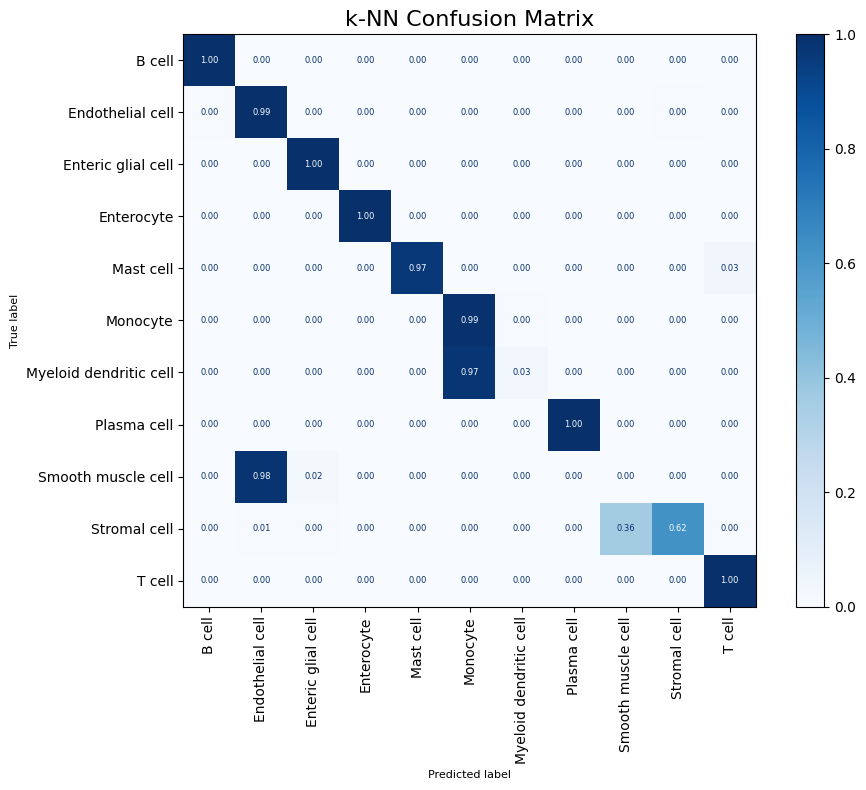

/tmp/ipykernel_822/2833621839.py:74: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data1.obs["y_pred_lr1"] = y_pred_lr1


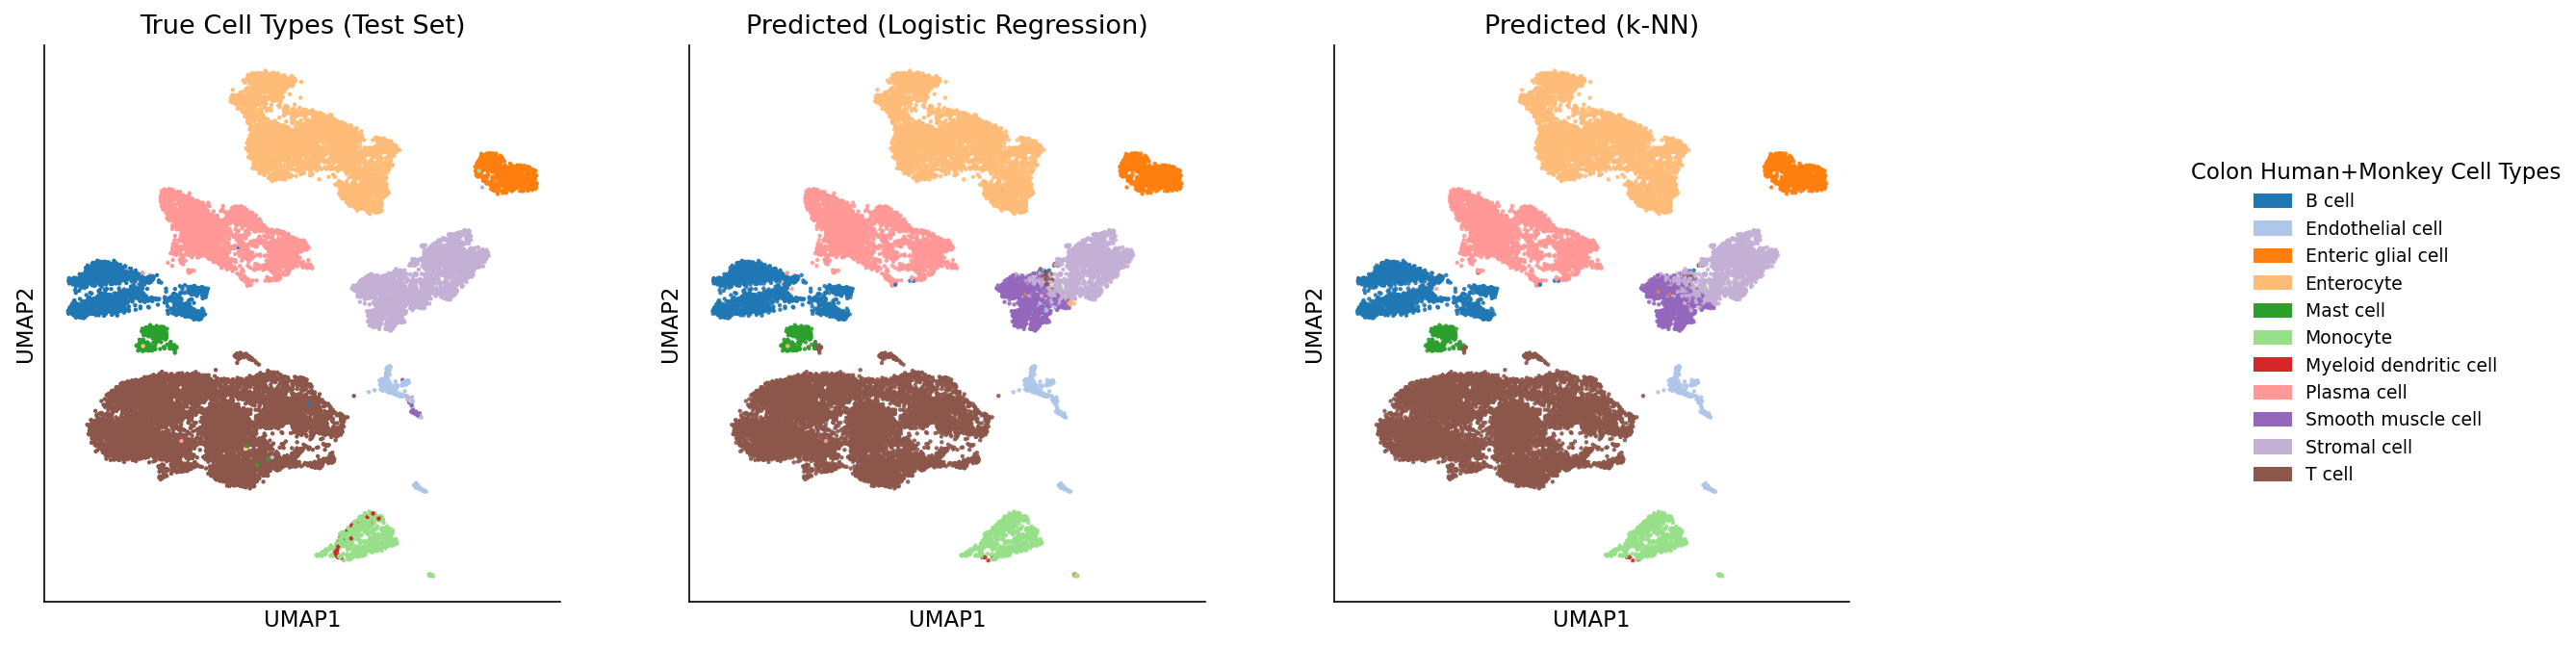

In [ ]:
train_data1 = adata[adata.obs["species"] == "monkey"]
test_data1  = adata[adata.obs["species"] != "monkey"]

X_train1 = train_data1.obsm["X_uce"]
X_test1  = test_data1.obsm["X_uce"]

y_train1 = train_data1.obs["cell_type"]
y_test1  = test_data1.obs["cell_type"]


# logistic regression
clf1 = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf1.fit(X_train1, y_train1)
y_pred_lr1 = clf1.predict(X_test1)

# KNN
knn1 = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn1.fit(X_train1, y_train1)
y_pred_knn1 = knn1.predict(X_test1)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test1, y_pred_lr1))
print(classification_report(y_test1, y_pred_lr1))
plot_cm(y_test1, y_pred_lr1, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test1, y_pred_knn1))
print(classification_report(y_test1, y_pred_knn1))
plot_cm(y_test1, y_pred_knn1, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data1.obs["y_pred_lr1"] = y_pred_lr1
test_data1.obs["y_pred_knn1"] = y_pred_knn1

# Fill missing values
test_data1.obs["y_pred_lr1"] = test_data1.obs["y_pred_lr1"].astype(str).fillna("Unassigned")
test_data1.obs["y_pred_knn1"] = test_data1.obs["y_pred_knn1"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data1.obs["cell_type"] = test_data1.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data1.obs["y_pred_lr1"] = test_data1.obs["y_pred_lr1"].astype("category")
test_data1.obs["y_pred_knn1"] = test_data1.obs["y_pred_knn1"].astype("category")

# Unified label set
all_labels1 = sorted(
    set(test_data1.obs["cell_type"].cat.categories)
    | set(test_data1.obs["y_pred_lr1"].cat.categories)
    | set(test_data1.obs["y_pred_knn1"].cat.categories)
)

# Force same category order
test_data1.obs["cell_type1"] = test_data1.obs["cell_type"].cat.set_categories(all_labels1)
test_data1.obs["y_pred_lr1"] = test_data1.obs["y_pred_lr1"].cat.set_categories(all_labels1)
test_data1.obs["y_pred_knn1"] = test_data1.obs["y_pred_knn1"].cat.set_categories(all_labels1)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels1)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data1, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data1, color="y_pred_lr1", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data1, color="y_pred_knn1", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels1]
fig.legend(
    handles=handles,
    title="Colon Human+Monkey Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()